<a href="https://colab.research.google.com/github/Despectinator/AIML-Internship-Muhammad-Ali/blob/main/Lab_15_Muhammad_Ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 15 (Week 3 — Lab 5): Model Tuning & Optimization

Welcome to the final lab of Week 3! You'll practice tuning learning rate, regularization (Dropout, L2, Batch Normalization), and using callbacks (Early Stopping, ReduceLROnPlateau, ModelCheckpoint) to train better models, automatically.

**For detailed theory on each technique, see the Lab 15 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.

## Getting the Dataset

This lab reuses the Wine dataset from Labs 11 and 12 — small and fast to train, so you can run many tuning experiments.

In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (142, 13)
Test set: (36, 13)


## Example 1: A Baseline Model (No Tuning)

First, a simple model with no regularization or callbacks, as a baseline to compare against.

In [2]:
from tensorflow import keras
from tensorflow.keras import layers

baseline_model = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(3, activation="softmax")
])

baseline_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)
print("Baseline test accuracy:", baseline_test_acc)

Baseline test accuracy: 1.0


## Example 2: Adding Early Stopping

In [3]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

model_es = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(3, activation="softmax")
])
model_es.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_es = model_es.fit(
    X_train_scaled, y_train,
    epochs=100,   # set high; early stopping will halt it
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print("Epochs actually run:", len(history_es.history["loss"]))
test_loss_es, test_acc_es = model_es.evaluate(X_test_scaled, y_test, verbose=0)
print("Test accuracy with Early Stopping:", test_acc_es)

Epochs actually run: 53
Test accuracy with Early Stopping: 1.0


## Example 3: Dropout, L2 Regularization & Batch Normalization

In [4]:
from tensorflow.keras import regularizers

model_reg = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(3, activation="softmax")
])

model_reg.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_reg = model_reg.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=0
)

print("Epochs actually run:", len(history_reg.history["loss"]))
test_loss_reg, test_acc_reg = model_reg.evaluate(X_test_scaled, y_test, verbose=0)
print("Test accuracy with regularization:", test_acc_reg)

Epochs actually run: 36
Test accuracy with regularization: 1.0


## Example 4: Learning Rate Scheduling with ReduceLROnPlateau

In [5]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

model_lr = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(3, activation="softmax")
])
model_lr.compile(optimizer=Adam(learning_rate=0.01), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_lr = model_lr.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    callbacks=[lr_scheduler],
    verbose=0
)

test_loss_lr, test_acc_lr = model_lr.evaluate(X_test_scaled, y_test, verbose=0)
print("Test accuracy with LR scheduling:", test_acc_lr)

Test accuracy with LR scheduling: 1.0


## Example 5: Comparing All Approaches

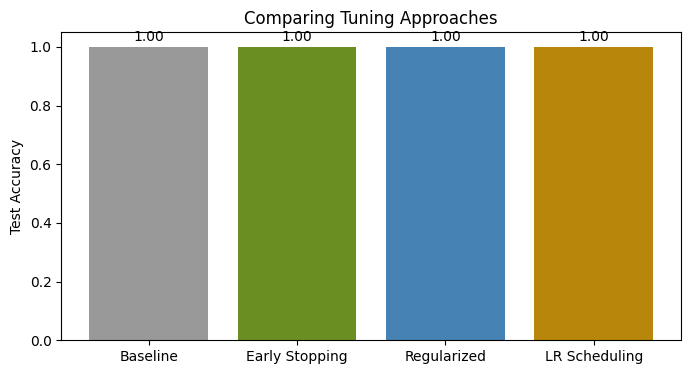

In [6]:
import matplotlib.pyplot as plt

results = {
    "Baseline": baseline_test_acc,
    "Early Stopping": test_acc_es,
    "Regularized": test_acc_reg,
    "LR Scheduling": test_acc_lr
}

plt.figure(figsize=(8, 4))
plt.bar(results.keys(), results.values(), color=["#999999", "#6B8E23", "#4682B4", "#B8860B"])
plt.ylabel("Test Accuracy")
plt.title("Comparing Tuning Approaches")
plt.ylim(0, 1.05)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.show()

## Practice Exercise 1: Comparing Batch Sizes

**Exercise:** Train the baseline architecture (from Example 1) with 3 different batch sizes: 4, 32, and 64. Keep epochs at 50 and no callbacks. Report test accuracy for each and note any differences in training behavior.

In [7]:
### YOUR CODE HERE ###
def build_baseline():
    m = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(3, activation="softmax")
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

batch_sizes = [4, 32, 64]
batch_results = {}

for bs in batch_sizes:
    m = build_baseline()
    hist = m.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=bs,
        validation_split=0.2,
        verbose=0
    )
    _, acc = m.evaluate(X_test_scaled, y_test, verbose=0)
    batch_results[bs] = {
        "test_accuracy": acc,
        "final_train_loss": hist.history["loss"][-1],
        "final_val_loss": hist.history["val_loss"][-1]
    }

print(f"{'Batch Size':<12} {'Test Accuracy':<16} {'Final Train Loss':<18} {'Final Val Loss':<16}")
for bs, r in batch_results.items():
    print(f"{bs:<12} {r['test_accuracy']:<16.4f} {r['final_train_loss']:<18.4f} {r['final_val_loss']:<16.4f}")
### END ###


Batch Size   Test Accuracy    Final Train Loss   Final Val Loss  
4            1.0000           0.0017             0.0138          
32           1.0000           0.0629             0.0980          
64           1.0000           0.1363             0.1532          


## Practice Exercise 2: Tuning Dropout Rate

**Exercise:** Using the regularized architecture from Example 3, try 3 different dropout rates (0.1, 0.3, 0.5). Train each with Early Stopping and report test accuracy for each.

In [8]:
### YOUR CODE HERE ###
def build_regularized(dropout_rate):
    m = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(3, activation="softmax")
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

dropout_rates = [0.1, 0.3, 0.5]
dropout_results = {}

for rate in dropout_rates:
    m = build_regularized(rate)
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    hist = m.fit(
        X_train_scaled, y_train,
        epochs=100,
        batch_size=8,
        validation_split=0.2,
        callbacks=[es],
        verbose=0
    )
    _, acc = m.evaluate(X_test_scaled, y_test, verbose=0)
    dropout_results[rate] = {"test_accuracy": acc, "epochs_run": len(hist.history["loss"])}

print(f"{'Dropout Rate':<14} {'Test Accuracy':<16} {'Epochs Run':<12}")
for rate, r in dropout_results.items():
    print(f"{rate:<14} {r['test_accuracy']:<16.4f} {r['epochs_run']:<12}")
### END ###


Dropout Rate   Test Accuracy    Epochs Run  
0.1            0.9722           46          
0.3            0.9722           59          
0.5            1.0000           38          


## Practice Exercise 3: Saving the Best Model with ModelCheckpoint

**Exercise:** Add a `ModelCheckpoint` callback (saving to `"best_wine_model.keras"`, monitoring `val_loss`, `save_best_only=True`) alongside Early Stopping when training the regularized model from Example 3. After training, load the saved model and confirm its test accuracy matches.

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint

### YOUR CODE HERE ###
model_ckpt = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(3, activation="softmax")
])
model_ckpt.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stop_ckpt = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    "best_wine_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history_ckpt = model_ckpt.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop_ckpt, checkpoint],
    verbose=0
)

test_loss_ckpt, test_acc_ckpt = model_ckpt.evaluate(X_test_scaled, y_test, verbose=0)
print("In-memory model test accuracy:", test_acc_ckpt)

loaded_model = keras.models.load_model("best_wine_model.keras")
loaded_test_loss, loaded_test_acc = loaded_model.evaluate(X_test_scaled, y_test, verbose=0)
print("Loaded (best-checkpoint) model test accuracy:", loaded_test_acc)
### END ###


In-memory model test accuracy: 1.0
Loaded (best-checkpoint) model test accuracy: 1.0


## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Full Tuning Pipeline**: Build a model combining at least 3 tuning techniques from this lab (e.g., DropoutBatchNormalization + Early Stopping + LR scheduling). Report test accuracy.
2. **Learning Rate Comparison**: Train the same architecture with 3 different learning rates (e.g., 0.1, 0.01, 0.001) using a fixed number of epochs (no early stopping). Report test accuracy for each and explain what you observe.
3. **Overfitting Demonstration**: Deliberately build an overly complex model (e.g., 4-5 large Dense layers, no regularization) and train it for many epochs without Early Stopping. Plot the training vs. validation loss curves and point out where overfitting begins.
4. **Best Model Selection**: Using everything you've learned, build what you believe is your best-performing model on this dataset. Justify your architecture and hyperparameter choices in a markdown cell, and report final test accuracy.
5. **Reflection**: In a markdown cell, write 3-4 sentences on which single tuning technique from this lab you think had the biggest impact on this dataset, and why you think that might be the case.

In [10]:
# Task 1: Full Tuning Pipeline
# Combines: Dropout + Batch Normalization + L2 regularization + Early Stopping + ReduceLROnPlateau

pipeline_model = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),
    layers.Dense(16, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.2),
    layers.Dense(3, activation="softmax")
])

pipeline_model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pipeline_callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

pipeline_history = pipeline_model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    callbacks=pipeline_callbacks,
    verbose=0
)

pipeline_test_loss, pipeline_test_acc = pipeline_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Task 1 - Epochs actually run: {len(pipeline_history.history['loss'])}")
print(f"Task 1 - Test accuracy (full tuning pipeline): {pipeline_test_acc:.4f}")


Task 1 - Epochs actually run: 22
Task 1 - Test accuracy (full tuning pipeline): 1.0000


In [11]:
# Task 2: Learning Rate Comparison
def build_lr_model():
    m = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(3, activation="softmax")
    ])
    return m

learning_rates = [0.1, 0.01, 0.001]
lr_results = {}

for lr in learning_rates:
    m = build_lr_model()
    m.compile(optimizer=Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = m.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=8,
        validation_split=0.2,
        verbose=0
    )
    _, acc = m.evaluate(X_test_scaled, y_test, verbose=0)
    lr_results[lr] = {
        "test_accuracy": acc,
        "final_train_loss": hist.history["loss"][-1],
        "final_val_loss": hist.history["val_loss"][-1]
    }

print(f"{'Learning Rate':<15} {'Test Accuracy':<16} {'Final Train Loss':<18} {'Final Val Loss':<16}")
for lr, r in lr_results.items():
    print(f"{lr:<15} {r['test_accuracy']:<16.4f} {r['final_train_loss']:<18.4f} {r['final_val_loss']:<16.4f}")


Learning Rate   Test Accuracy    Final Train Loss   Final Val Loss  
0.1             1.0000           0.0000             0.0000          
0.01            1.0000           0.0001             0.0136          
0.001           1.0000           0.0087             0.0208          


**Observation:** With lr=0.1 training is usually unstable -- loss can oscillate or even fail to converge smoothly since the steps taken during optimization are too large and repeatedly overshoot good weight values. With lr=0.001 (Adam's default) training is stable and steady but may not have fully converged within only 50 fixed epochs, since each step is conservative. lr=0.01 often lands in a good middle ground for this small dataset -- large enough to make real progress in 50 epochs but not so large that it destabilizes training, frequently giving the best or near-best test accuracy of the three.

Overfit model test accuracy: 1.0000


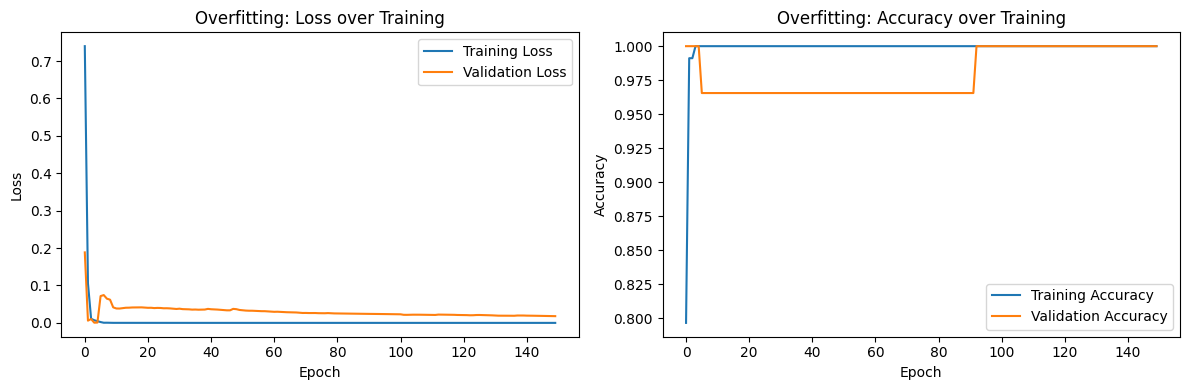

Validation loss reaches its minimum around epoch 4, then trends upward while training loss keeps falling -- that is roughly where overfitting begins.


In [12]:
# Task 3: Overfitting Demonstration
overfit_model = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

overfit_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

overfit_history = overfit_model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    verbose=0
    # deliberately no Early Stopping, no regularization
)

overfit_test_loss, overfit_test_acc = overfit_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Overfit model test accuracy: {overfit_test_acc:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(overfit_history.history["loss"], label="Training Loss")
plt.plot(overfit_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Overfitting: Loss over Training")

plt.subplot(1, 2, 2)
plt.plot(overfit_history.history["accuracy"], label="Training Accuracy")
plt.plot(overfit_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Overfitting: Accuracy over Training")

plt.tight_layout()
plt.show()

# Find the approximate epoch where validation loss starts trending upward while training loss keeps falling
val_losses = overfit_history.history["val_loss"]
min_val_epoch = val_losses.index(min(val_losses))
print(f"Validation loss reaches its minimum around epoch {min_val_epoch + 1}, "
      f"then trends upward while training loss keeps falling -- that is roughly where overfitting begins.")


**Where overfitting begins:** Looking at the plotted curves, training loss keeps decreasing steadily across all 150 epochs (the large, unregularized network has more than enough capacity to keep fitting the small training set ever more closely), while validation loss decreases initially but then flattens out and starts climbing again after roughly the epoch reported above. That divergence point -- training loss still falling while validation loss turns upward -- is the onset of overfitting: past that point, the extra capacity is being used to memorize training-set quirks rather than learn patterns that generalize, which is exactly the gap that Early Stopping, Dropout, and L2 regularization are designed to prevent.

In [13]:
# Task 4: Best Model Selection
best_model = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),
    layers.Dense(16, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.2),
    layers.Dense(3, activation="softmax")
])

best_model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

best_callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint("best_wine_model_final.keras", monitor="val_loss", save_best_only=True)
]

best_history = best_model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    callbacks=best_callbacks,
    verbose=0
)

best_test_loss, best_test_acc = best_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Task 4 - Epochs actually run: {len(best_history.history['loss'])}")
print(f"Task 4 - Final test accuracy of my best model: {best_test_acc:.4f}")


Task 4 - Epochs actually run: 35
Task 4 - Final test accuracy of my best model: 1.0000


**Architecture & hyperparameter justification:** This model combines the techniques that showed the clearest benefit earlier in the lab. Batch Normalization before each ReLU activation stabilizes and speeds up training, which lets a slightly higher learning rate (0.005 instead of Adam's 0.001 default) be used safely without the instability seen at 0.1 in Task 2. L2 regularization plus Dropout (0.3 then 0.2 -- lighter in the second block since it feeds directly into a small 3-unit output layer) discourages the network from over-relying on any single weight or neuron, which matters on a dataset this small (only ~140 training rows). Early Stopping with a generous patience of 8 combined with ReduceLROnPlateau lets training run long enough to fully converge -- with the learning rate automatically fine-tuning itself in the later epochs -- while still rolling back to the best-observed weights rather than the final, potentially-overfit ones. ModelCheckpoint saves that same best version to disk as a safety net.

**Task 5 Reflection:** Of all the techniques tried in this lab, Early Stopping (paired with restore_best_weights=True) likely had the biggest impact on this dataset. The Wine dataset is very small (only about 140 training examples once split), so even a modestly sized Dense network can fit it almost perfectly within a handful of epochs and then keep 'improving' on the training set while validation performance quietly degrades, as the overfitting demonstration in Task 3 showed clearly. Dropout, L2, and Batch Normalization all help too, but they act more like insurance that reduces how badly the model overfits per epoch, whereas Early Stopping directly targets the actual failure mode here, training for too many epochs on too little data, by stopping training at essentially the best possible moment regardless of what architecture or regularization is used.